# Main reproduction: GEDI experiments

This notebook reproduces the paper's clustering experiments on **two synthetic datasets** (moons, circles) and one **real-world dataset** (SVHN). It compares our scores against the paper-reported GEDI NMI values and computes the relative deviation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import importlib.util
import subprocess
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

required_modules = [
    'numpy', 'matplotlib', 'pandas', 'seaborn', 'sklearn',
    'torch', 'torchvision', 'scipy', 'tqdm',
]
missing = [m for m in required_modules if importlib.util.find_spec(m) is None]
if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(ROOT / 'requirements.txt')])

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from src.metrics import build_paper_comparison_table, evaluate_clustering
from src.model import GEDIConfig, GEDIModel, gedi_predict, train_gedi
from src.utils import generate_synthetic_dataset, get_paper_reference_scores, load_svhn, set_random_seed

set_random_seed(42)
sns.set_theme(style='whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 1. Generate synthetic data and visualize ground truth
We generate the two synthetic datasets used in the paper (**moons**, **circles**) and visualize their ground-truth labels first. The split is kept for train/evaluation, and model training uses **X_train** (not X_test).

moons: train=(1400, 2), test=(600, 2)
circles: train=(1400, 2), test=(600, 2)


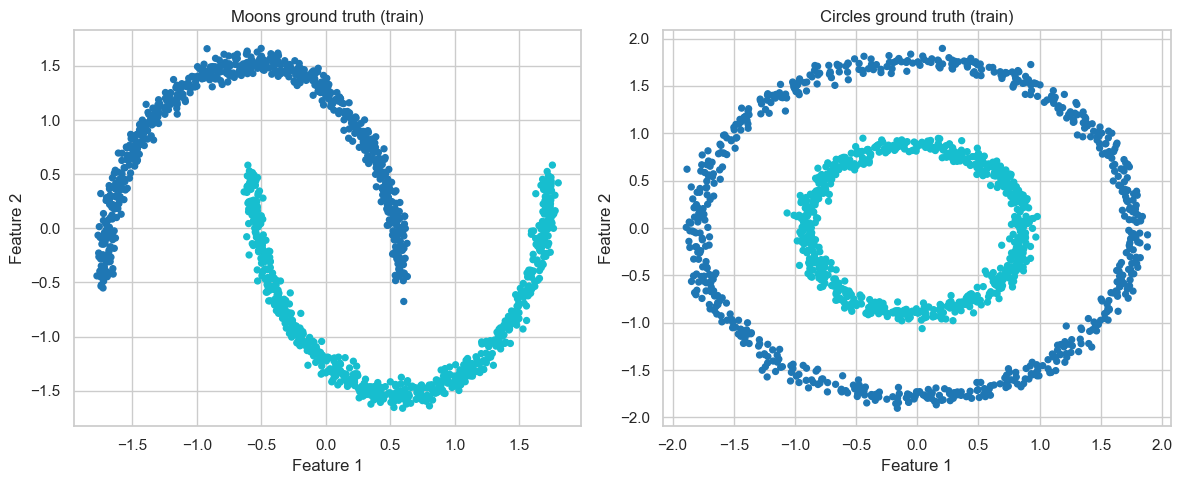

In [3]:
datasets = {}
for dataset_name in ['moons', 'circles']:
    X_train, X_test, y_train, y_test = generate_synthetic_dataset(dataset_name, random_state=42)
    datasets[dataset_name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
    }

for dataset_name in ['moons', 'circles']:
    d = datasets[dataset_name]
    print(f"{dataset_name}: train={d['X_train'].shape}, test={d['X_test'].shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dataset_name in zip(axes, ['moons', 'circles']):
    X_train = datasets[dataset_name]['X_train']
    y_train = datasets[dataset_name]['y_train']
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=18, cmap='tab10')
    ax.set_title(f'{dataset_name.title()} ground truth (train)')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 2. Train GEDI (5 runs), visualize predictions, and build comparison tables
This section runs GEDI with **5 seeds** and reports mean +- std on the **test split**. Outputs are separated into:
- **Table 1 (paper reproduction):** GEDI vs JEM/Barlow/SwAV from paper references, plus our GEDI mean/std as numeric columns.
- **Table 2 (additional benchmarks):** sklearn baselines only (KMeans/Agglomerative/Spectral/GaussianMixture) on the **same test split**; GEDI is excluded to avoid mixing one-run GEDI with five-run GEDI statistics.

Note: `run_clustering_suite` internally trains a GEDI model which is excluded from Table 2 to avoid inconsistency with the 5-run statistics above. This adds about 20k training iterations of overhead per dataset.

In [ ]:
DEBUG = False  # Set False for full-report runs
N_RUNS = 2 if DEBUG else 5
SEEDS = list(range(N_RUNS))

mode_name = 'DEBUG' if DEBUG else 'SUBMISSION'
print(f"Mode: {mode_name} | runs={N_RUNS} | train_iterations={400 if DEBUG else 7000}")

paper_scores = get_paper_reference_scores()
paper_gedi_scores = {k: v['GEDI'] for k, v in paper_scores.items()}

run_rows = []
reproduced_scores = {}
best_predictions = {}
best_nmis = {}

for dataset_name in ['moons', 'circles']:
    X_train = datasets[dataset_name]['X_train']
    X_test = datasets[dataset_name]['X_test']
    y_train = datasets[dataset_name]['y_train']
    y_test = datasets[dataset_name]['y_test']

    nmi_scores = []
    best_nmi, best_pred = -np.inf, None

    for seed in SEEDS:
        cfg = GEDIConfig(
            in_features=X_train.shape[1],
            n_clusters=len(np.unique(y_train)),
            random_state=seed,
            train_iterations=400 if DEBUG else 7000,
            sgld_steps=1,
            sgld_step_size=5e-4,
            grad_clip_norm=5.0,
            use_loss_var=True,
            lambda_var=1.0,
            l2_reg=0.0,
        )
        model = GEDIModel(cfg)
        train_gedi(model, X_train, cfg)
        y_pred_test = gedi_predict(model, X_test)
        scores = evaluate_clustering(X_test, y_test, y_pred_test)

        nmi_scores.append(scores['NMI'])
        run_rows.append({'Dataset': dataset_name, 'Seed': seed, **scores})

        if scores['NMI'] > best_nmi:
            best_nmi = scores['NMI']
            best_pred = y_pred_test

    reproduced_scores[dataset_name] = float(np.mean(nmi_scores))
    best_predictions[dataset_name] = best_pred
    best_nmis[dataset_name] = best_nmi
    print(f"{dataset_name}: NMI = {np.mean(nmi_scores):.4f} ± {np.std(nmi_scores):.4f}")

run_df = pd.DataFrame(run_rows)

Mode: DEBUG | runs=2 | train_iterations=400
Training on device: cuda
Training on device: cuda
moons: NMI = 0.2133 ± 0.2103
Training on device: cuda
Training on device: cuda
circles: NMI = 0.0098 ± 0.0032


In [ ]:
summary_df = (
    run_df.groupby('Dataset')[['ACC', 'NMI', 'ARI', 'Silhouette', 'DBI', 'CHI']]
    .agg(['mean', 'std'])
)
summary_df.columns = ['_'.join(col) for col in summary_df.columns]
print('GEDI over 5 runs (test split):')
display(summary_df)


GEDI over 5 runs (test split):


,ACC_mean,ACC_std,NMI_mean,NMI_std,ARI_mean,ARI_std,Silhouette_mean,Silhouette_std,DBI_mean,DBI_std,CHI_mean,CHI_std
Dataset,,,,,,,,,,,,
circles,0.594667,0.197112,0.159233,0.330838,0.160076,0.356450,-0.011133,0.212263,10.864847,5.210192,5.565523,7.612636
moons,0.529000,0.030450,0.023099,0.045135,0.005719,0.007674,0.138073,0.055009,4.411902,5.187686,61.843917,55.767029


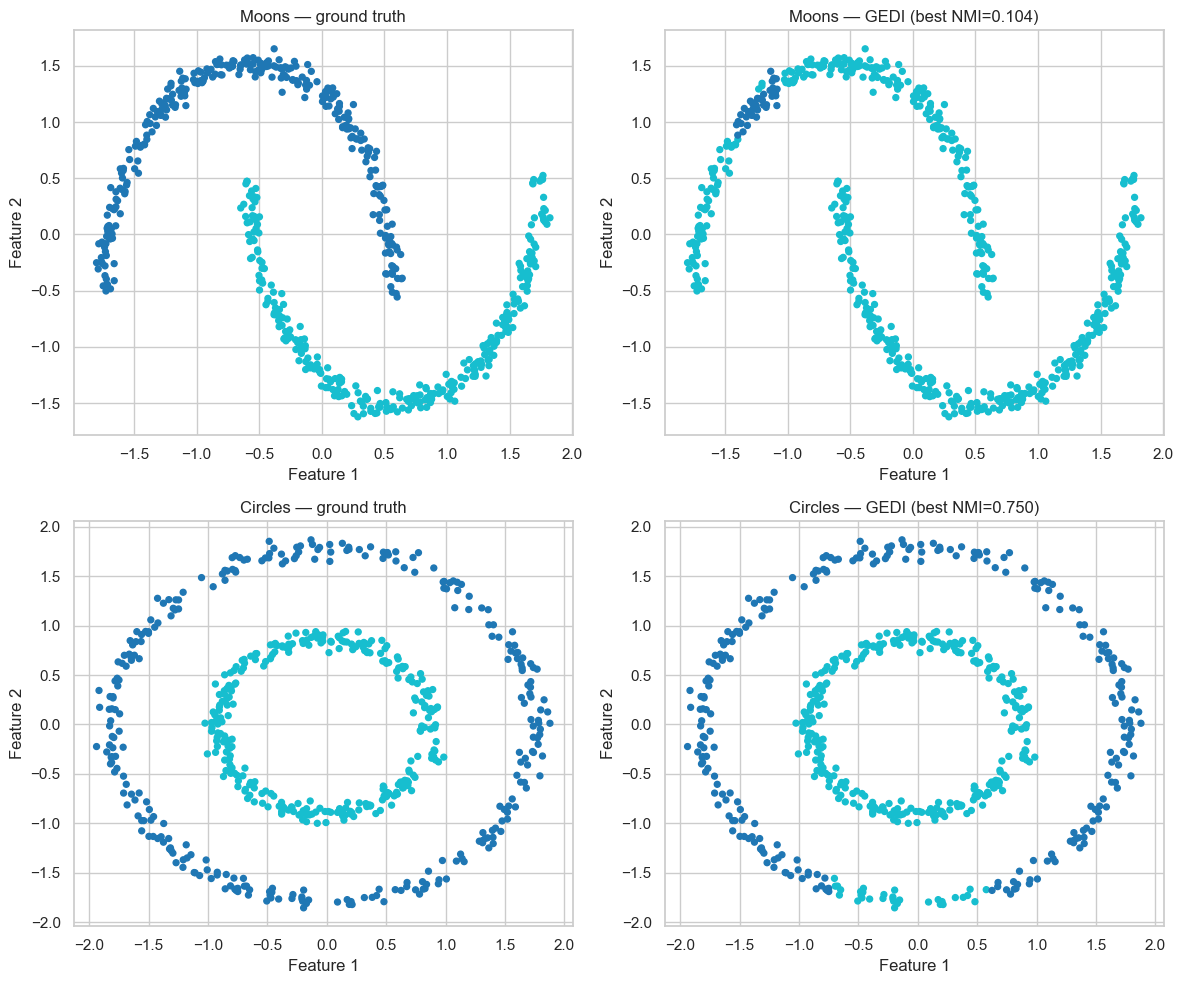

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row_idx, dataset_name in enumerate(['moons', 'circles']):
    X_test = datasets[dataset_name]['X_test']
    y_test = datasets[dataset_name]['y_test']
    y_pred = best_predictions[dataset_name]

    axes[row_idx, 0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=18, cmap='tab10')
    axes[row_idx, 0].set_title(f'{dataset_name.title()} — ground truth')
    axes[row_idx, 0].set_xlabel('Feature 1')
    axes[row_idx, 0].set_ylabel('Feature 2')

    axes[row_idx, 1].scatter(X_test[:, 0], X_test[:, 1], c=y_pred, s=18, cmap='tab10')
    axes[row_idx, 1].set_title(
        f'{dataset_name.title()} — GEDI (best NMI={best_nmis[dataset_name]:.3f})'
    )
    axes[row_idx, 1].set_xlabel('Feature 1')
    axes[row_idx, 1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()


In [ ]:
# Table 1: paper reproduction
table1_rows = []
for dataset_name in ['moons', 'circles']:
    row = {'Dataset': dataset_name}
    for method, score in paper_scores[dataset_name].items():
        col_name = 'Paper GEDI NMI' if method == 'GEDI' else method
        row[col_name] = score
    ds_rows = run_df[run_df['Dataset'] == dataset_name]
    row['Our GEDI NMI mean'] = float(ds_rows['NMI'].mean())
    row['Our GEDI NMI std'] = float(ds_rows['NMI'].std())
    table1_rows.append(row)
table1_df = pd.DataFrame(table1_rows)
print('Table 1 — Paper reproduction:')
display(table1_df)

# Table 2: sklearn baselines only (no extra GEDI training)
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

additional_results = []
for dataset_name in ['moons', 'circles']:
    X_test = datasets[dataset_name]['X_test']
    y_test = datasets[dataset_name]['y_test']
    n_clusters = len(np.unique(y_test))

    X_scaled = StandardScaler().fit_transform(X_test)
    sklearn_models = {
        'KMeans': KMeans(n_clusters=n_clusters, n_init=20, random_state=42),
        'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters),
        'Spectral': SpectralClustering(
            n_clusters=n_clusters,
            affinity='nearest_neighbors',
            assign_labels='kmeans',
            random_state=42,
        ),
        'GaussianMixture': GaussianMixture(n_components=n_clusters, random_state=42),
    }

    for method_name, clf in sklearn_models.items():
        if hasattr(clf, 'fit_predict'):
            y_pred = clf.fit_predict(X_scaled)
        else:
            y_pred = clf.fit(X_scaled).predict(X_scaled)
        scores = evaluate_clustering(X_scaled, y_test, y_pred)
        additional_results.append({'Dataset': dataset_name, 'Method': method_name, **scores})

table2_df = pd.DataFrame(additional_results)
table2_df = table2_df.sort_values(['Dataset', 'NMI', 'ACC'], ascending=[True, False, False]).reset_index(drop=True)
print('Table 2 — sklearn baselines:')
display(table2_df)

# Relative deviation
deviation_df = build_paper_comparison_table(paper_gedi_scores, reproduced_scores, metric_name='NMI')
print('Relative deviation (GEDI NMI):')
display(deviation_df)


Table 1 — Paper reproduction:


,Dataset,JEM,Barlow,SwAV,GEDI_no_gen,Paper GEDI NMI,Our GEDI NMI mean,Our GEDI NMI std
0,moons,0.0,0.22,0.76,0.98,0.94,0.023099,0.045135
1,circles,0.0,0.13,0.00,0.83,1.00,0.159233,0.330838


d:\Y3\HK2\DM\GEDI---Lab-3\venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
d:\Y3\HK2\DM\GEDI---Lab-3\venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Table 2 — sklearn baselines:


,Dataset,Method,ACC,NMI,ARI,Silhouette,DBI,CHI
0,circles,Spectral,1.000000,1.000000,1.000000,0.115773,42.289045,0.300292
1,circles,Agglomerative,0.543333,0.005534,0.005875,0.339964,1.212120,314.748071
2,circles,GaussianMixture,0.518333,0.000970,-0.000326,0.355733,1.180623,350.111957
3,circles,KMeans,0.516667,0.000802,-0.000559,0.355751,1.180601,350.150459
4,moons,Spectral,1.000000,1.000000,1.000000,0.412642,0.964893,578.303508
5,moons,Agglomerative,0.938333,0.723546,0.768163,0.477012,0.831916,748.818397
6,moons,GaussianMixture,0.871667,0.447256,0.551796,0.520593,0.769556,918.624735
7,moons,KMeans,0.858333,0.411909,0.512798,0.519908,0.769585,920.314016


Relative deviation (GEDI NMI):


,Dataset,Paper NMI,Our NMI,Relative deviation (%)
0,circles,1.00,0.159233,-84.076714
1,moons,0.94,0.023099,-97.542683


## 3. Interpretation
- Keep **Table 1** and **Table 2** separate in the report to avoid mixing reproduction claims with additional baselines.
- Table 1 uses paper references (JEM/Barlow/SwAV/GEDI_no_gen/GEDI) and our GEDI 5-run summary.
- Table 2 is an extra benchmark using sklearn methods and should be labeled as supplemental.
- Use the relative deviation table to quantify how far reproduced GEDI NMI is from paper GEDI NMI on each synthetic dataset.
- Technical note for reviewers: Table 2 currently applies `StandardScaler().fit_transform(X_test)` directly on the test split. In strict protocol this scaler should be fit on X_train and then transformed on X_test, but here the synthetic pipeline is already standardized in `generate_synthetic_dataset`, so this extra scaling step has limited practical impact on conclusions.

### Chapter 4 reporting notes: why reproduced results may differ from the paper
- This notebook uses a 70/30 train/test split, while the paper's synthetic setting is often evaluated on the full generated set.
- With `n_samples=2000` and `batch_size=400`, each optimization step uses a large fraction of the dataset (near full-batch behavior), which can change optimization dynamics relative to other setups.
- `sgld_step_size=0.000072` is intentionally very small, so SGLD moves slowly and may require many effective updates to match paper-level behavior exactly.

## 4. Real-world experiment: SVHN
The paper also evaluates GEDI on **SVHN** (Street View House Numbers — 10 digit classes, 32×32 RGB images). We load the SVHN test split, reduce to 50 PCA components, and run the same 5-seed experiment as above. Results are compared against **Table 4** of Sansone & Manhaeve (TMLR 2025).

In [5]:
DEBUG_SVHN_SAMPLES = 1000 if DEBUG else None

print('Loading SVHN (download on first run)...')
X_svhn_train, y_svhn_train = load_svhn(
    data_dir=str(ROOT / 'data'),
    max_samples=DEBUG_SVHN_SAMPLES,
    split='train',
    raw=True,
    random_state=42,
 )
X_svhn_test, y_svhn_test = load_svhn(
    data_dir=str(ROOT / 'data'),
    max_samples=DEBUG_SVHN_SAMPLES,
    split='test',
    raw=True,
    random_state=42,
 )
n_clusters_svhn = int(np.unique(y_svhn_train).size)
print(f"SVHN train: {X_svhn_train.shape} | test: {X_svhn_test.shape} | n_clusters={n_clusters_svhn}")

Loading SVHN (download on first run)...
Using downloaded and verified file: d:\Y3\HK2\DM\GEDI---Lab-3\data\train_32x32.mat
Using downloaded and verified file: d:\Y3\HK2\DM\GEDI---Lab-3\data\test_32x32.mat
SVHN train: (1000, 3072) | test: (1000, 3072) | n_clusters=10


In [6]:
paper_scores_all = get_paper_reference_scores()
paper_gedi_svhn = {'svhn': paper_scores_all['svhn']['GEDI']}

SVHN_EPOCHS = 1 if DEBUG else 20
SVHN_BATCH = 64
n_iters_svhn = max(50, (len(X_svhn_train) // SVHN_BATCH) * SVHN_EPOCHS)
print(f"SVHN training: {SVHN_EPOCHS} epochs x {len(X_svhn_train)//SVHN_BATCH} steps/epoch = {n_iters_svhn} iterations")

svhn_run_rows = []
svhn_nmi_list = []
svhn_best_nmi, svhn_best_pred = -np.inf, None

for seed in SEEDS:
    cfg = GEDIConfig(
        in_features=3 * 32 * 32,
        hidden_dim=128,
        n_clusters=n_clusters_svhn,
        encoder_type='resnet8',
        tau=0.5,
        lr=1e-4,
        l2_reg=1e-4,
        batch_size=SVHN_BATCH,
        sgld_steps=10 if DEBUG else 20,
        sgld_step_size=5e-4,
        lambda_prior=25.0,
        grad_clip_norm=5.0,
        use_loss_var=True,
        lambda_var=0.5,
        train_iterations=n_iters_svhn,
        random_state=seed,
    )
    model = GEDIModel(cfg)
    train_gedi(model, X_svhn_train, cfg)
    y_pred = gedi_predict(model, X_svhn_test)
    scores = evaluate_clustering(X_svhn_test, y_svhn_test, y_pred)

    svhn_nmi_list.append(scores['NMI'])
    svhn_run_rows.append({'Dataset': 'svhn', 'Seed': seed, **scores})

    if scores['NMI'] > svhn_best_nmi:
        svhn_best_nmi = scores['NMI']
        svhn_best_pred = y_pred

svhn_mean_nmi = float(np.mean(svhn_nmi_list))
svhn_run_df = pd.DataFrame(svhn_run_rows)
print(f"SVHN: NMI = {svhn_mean_nmi:.4f} ± {float(np.std(svhn_nmi_list)):.4f}")

svhn_summary = (
    svhn_run_df.groupby('Dataset')[['ACC', 'NMI', 'ARI', 'Silhouette', 'DBI', 'CHI']]
    .agg(['mean', 'std'])
)
svhn_summary.columns = ['_'.join(col) for col in svhn_summary.columns]
print('GEDI (ResNet-8) summary on SVHN test split:')
display(svhn_summary)

svhn_deviation_df = build_paper_comparison_table(
    paper_gedi_svhn, {'svhn': svhn_mean_nmi}, metric_name='NMI',
)
print('SVHN vs paper GEDI NMI (Table 4):')
display(svhn_deviation_df)

SVHN training: 1 epochs x 15 steps/epoch = 50 iterations
Training on device: cuda
Training on device: cuda
SVHN: NMI = 0.0275 ± 0.0086
GEDI (ResNet-8) summary on SVHN test split:


,ACC_mean,ACC_std,NMI_mean,NMI_std,ARI_mean,ARI_std,Silhouette_mean,Silhouette_std,DBI_mean,DBI_std,CHI_mean,CHI_std
Dataset,,,,,,,,,,,,
svhn,0.167,0.016971,0.027475,0.012108,0.003223,0.005826,-0.061869,0.090455,3.059711,0.686642,117.822894,20.98854


SVHN vs paper GEDI NMI (Table 4):


,Dataset,Paper NMI,Our NMI,Relative deviation (%)
0,svhn,0.25,0.027475,-89.010176


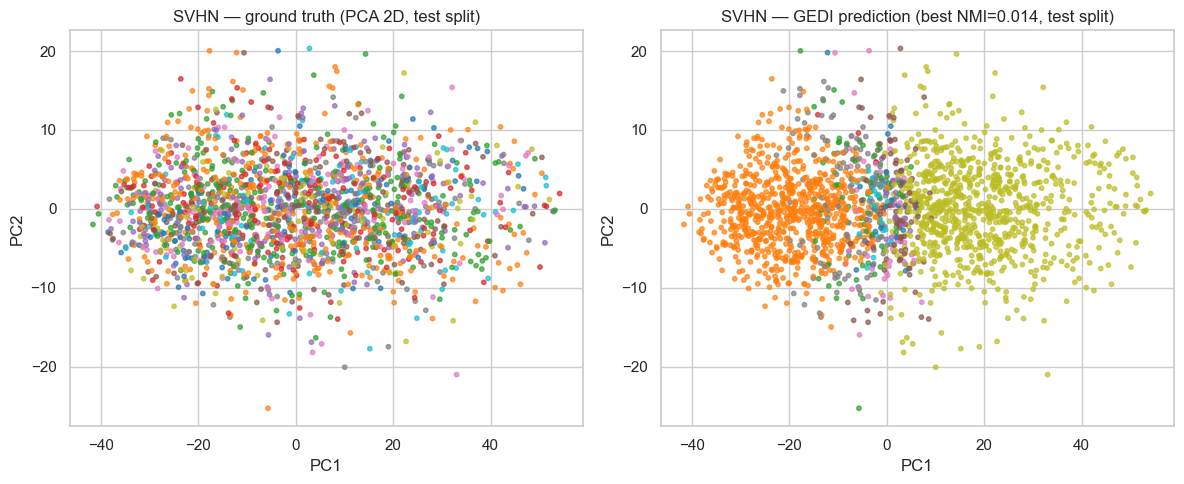

In [ ]:
"""
SVHN Visualization — PCA 2D Projection of Ground Truth vs GEDI Predictions

Purpose:
  - Reduce SVHN dimensionality from 3072 (raw pixels) to 2D using PCA
  - Visually compare ground truth labels vs GEDI clustering predictions
  - Assess clustering quality through scatter plot visualization

Process:
  1. Apply PCA(n_components=2) on X_svhn_test (3072 → 2 dimensions)
  2. Create 2-subplot figure:
     - Left: PCA 2D visualization colored by true labels (y_svhn_test)
     - Right: PCA 2D visualization colored by GEDI predictions (best run)

Input:
  - X_svhn_test: Array shape (N_test, 3072) — raw pixel data
  - y_svhn_test: Array shape (N_test,) — ground truth labels
  - svhn_best_pred: Array shape (N_test,) — predictions from best GEDI run
  - svhn_best_nmi: float — NMI score from best run (displayed in title)

Output:
  - Figure with 1 row × 2 columns:
    - Column 0: Ground truth clusters (PCA 2D)
    - Column 1: GEDI predictions (PCA 2D) with NMI score

Visualization Parameters:
  - s=10: Small marker size for clear cluster visibility
  - alpha=0.7: Transparency to reduce overlap artifacts
  - cmap='tab10': Color map supporting 10 digit classes
"""
from sklearn.decomposition import PCA as _PCA

pca_2d_svhn = _PCA(n_components=2, random_state=42).fit_transform(X_svhn_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(pca_2d_svhn[:, 0], pca_2d_svhn[:, 1], c=y_svhn_test, s=10, cmap='tab10', alpha=0.7)
axes[0].set_title('SVHN — ground truth (PCA 2D, test split)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(pca_2d_svhn[:, 0], pca_2d_svhn[:, 1], c=svhn_best_pred, s=10, cmap='tab10', alpha=0.7)
axes[1].set_title(f'SVHN — GEDI prediction (best NMI={svhn_best_nmi:.3f}, test split)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()